In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'

import pickle
import os

from tqdm.auto import tqdm

import schwingerModel as sim
from schwingerModel import wick

from scipy.optimize import curve_fit

In [2]:
with open('configs/50kSteps.pkl', 'rb') as f:
    model = pickle.load(f)

dimt = model.dimt

In [3]:
#GEVP basis with pion quantum numbers (I=1, I3=+1, P=-1, total momentum 0):
#single pions with 0 and 2 covariant derivatives, plus pipi(k,-k) I=1 operators
ops = sim.distillation.pionBasis(derivCounts=(0,2), pipiMomenta=(1,2))
opNames = [op.name for op in ops]
opNames

['pi_D0', 'pi_D2', 'pipi_I1_k1', 'pipi_I1_k2']

In [4]:
ti = 2
nVec = 8

#precompute the theta-INDEPENDENT per-config correlation data once; reweighting
#scans reuse it via interpGEVPStats(..., data=data, theta=...). cacheDir also
#persists perambulators/eigenbases/elementals as .npy so building a different
#operator basis later skips the Dirac solves too.
#burnIn=0: run_sim.py already discards the burn-in before saving linkHistory
dataFile = 'configs/50kSteps_pionBasis_distillData.pkl'
if os.path.exists(dataFile):
    with open(dataFile, 'rb') as f:
        data = pickle.load(f)
else:
    data = sim.distillation.computeInterpCorrelData(model, ops, burnIn=0, autocorrSkip=50,
                                                    numVecs=nVec, cacheDir='distillCache/50kSteps')
    with open(dataFile, 'wb') as f:
        pickle.dump(data, f)

#thermal-shifted GEVP: solved on Ctilde(t) = C(t) - C(t+1), which removes
#time-constant around-the-world contamination; eigenvalues decay as pure exponentials
out = sim.distillation.interpGEVPStats(model, ops, data=data, theta=0,
                                       ti=ti, numResamples=2000, thermalShift=True)

mean, errs, cov, refVecs = out
nOps = len(ops)
nT = mean.shape[0]

In [5]:
#operator content of each state (unit-normalized eigenvector magnitudes)
content = np.abs(refVecs) / np.linalg.norm(refVecs, axis=0)
print("            " + "  ".join(f"state{k}" for k in range(nOps)))
for iOp in range(nOps):
    print(f"{opNames[iOp]:>12}" + "  ".join(f"{content[iOp,k]:6.3f}" for k in range(nOps)))

            state0  state1  state2  state3
       pi_D0 0.529   0.104   0.265   0.490
       pi_D2 0.848   0.953   0.910   0.142
  pipi_I1_k1 0.025   0.286   0.319   0.003
  pipi_I1_k2 0.006   0.013   0.002   0.860


In [6]:
#exponential fits in log space with diagonal covariance and FREE amplitude:
#anchoring at the GEVP normalization lambda(ti)=1 biases E upward, since that
#point carries the most excited-state contamination
fitRanges = [[5,13], [2,8], [2,7], [1,5]]   #indices; actual t = idx + ti

masses = []
amps = []
for k in range(nOps):
    lo, hi = fitRanges[k]
    C  = mean[lo:hi, k]
    dC = np.sqrt(np.diag(cov[k]))[lo:hi]
    good = (C > 0) & np.isfinite(dC) & (dC > 0)

    expLog = lambda idx, E, logA: logA - idx*E

    popt, pcov = curve_fit(expLog, xdata=np.arange(lo,hi)[good], ydata=np.log(C[good]),
                           sigma=(dC/C)[good], absolute_sigma=True,
                           p0=[0.5, 0.0], bounds=([0,-np.inf],[np.inf,np.inf]))
    masses.append([popt[0], np.sqrt(pcov[0,0])])
    amps.append(popt[1])
    print(f"state {k}: aE = {popt[0]:.4f} +/- {np.sqrt(pcov[0,0]):.4f}  (fit t/a in [{lo+ti},{hi+ti}])")

state 0: aE = 0.5528 +/- 0.0008  (fit t/a in [7,15])
state 1: aE = 1.2879 +/- 0.0013  (fit t/a in [4,10])
state 2: aE = 1.4541 +/- 0.0015  (fit t/a in [4,9])
state 3: aE = 1.9308 +/- 0.0019  (fit t/a in [3,7])


In [7]:
#non-interacting two-pion levels from the fitted pion mass and lattice dispersion
mPi = masses[0][0]
def latticeE(m, k):
    #free boson lattice dispersion: sinh^2(E/2) = sinh^2(m/2) + sin^2(pi k/L)
    return 2*np.arcsinh(np.sqrt(np.sinh(m/2)**2 + np.sin(np.pi*k/model.dimx)**2))
freeLevels = {k: 2*latticeE(mPi, k) for k in (1,2)}
freeLevels

{1: np.float64(1.3395746420057204), 2: np.float64(1.8318047424142447)}

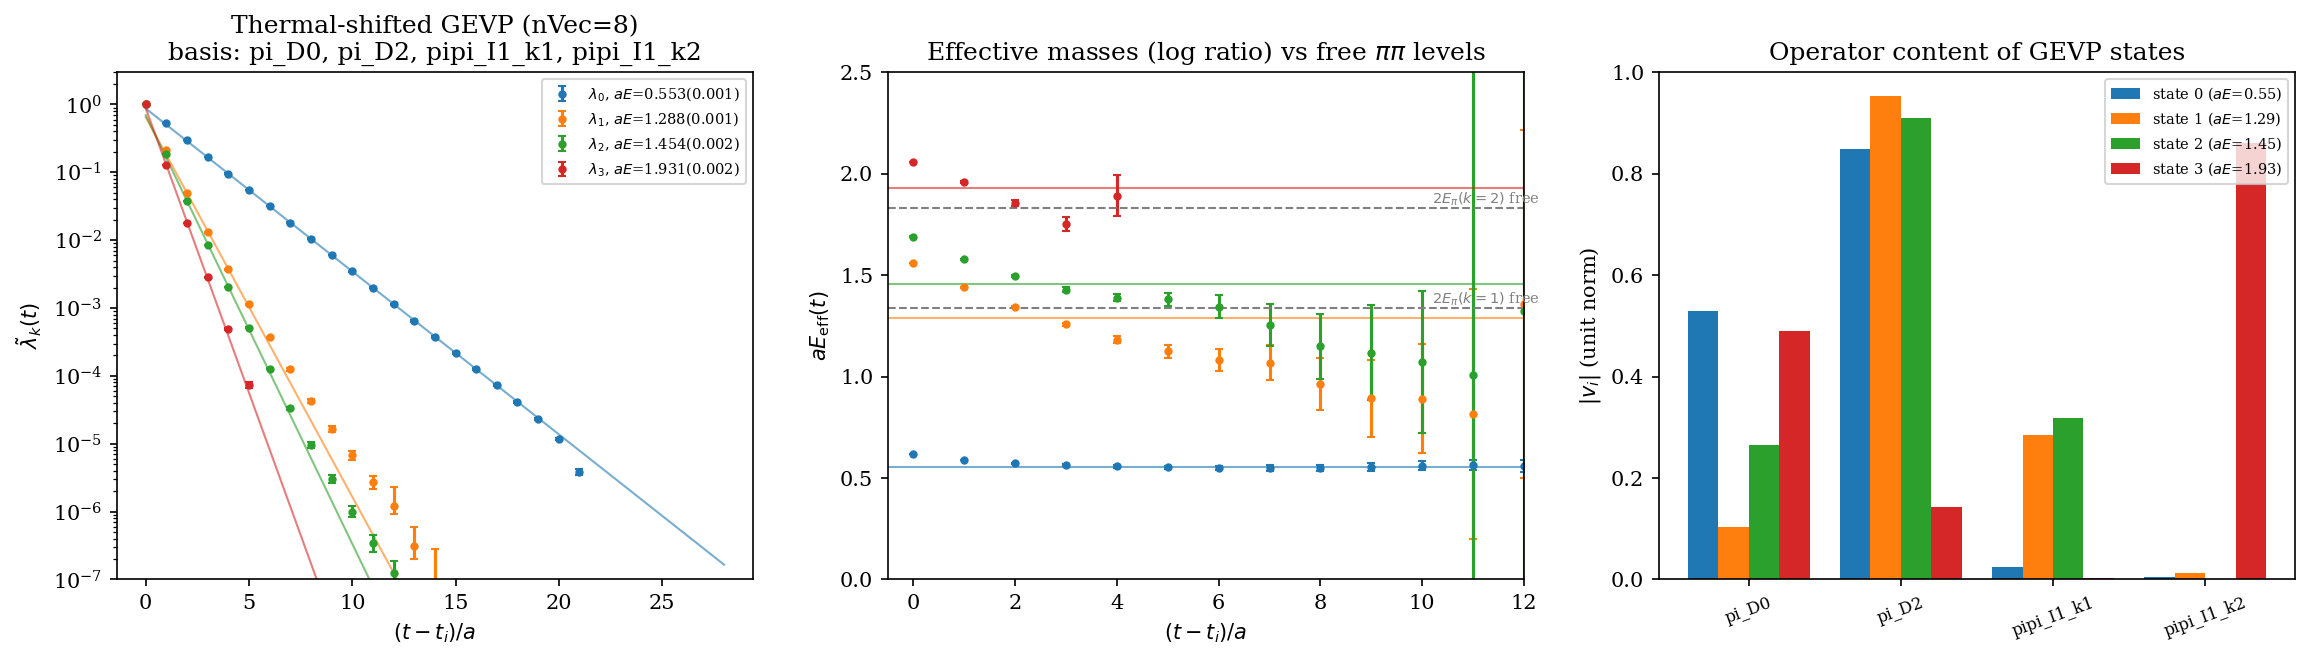

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15.5,4.5), dpi=150)
ts = np.arange(nT)
colors = ['C0','C1','C2','C3']

for k in range(nOps):
    axes[0].errorbar(ts, mean[:,k], yerr=errs[:,:,k], fmt='o', ms=3, capsize=2, color=colors[k],
                     label=f"$\\lambda_{k}$, $aE$={masses[k][0]:.3f}({masses[k][1]:.3f})")
    nts = np.linspace(0, nT-1, 200)
    axes[0].plot(nts, np.exp(amps[k] - nts*masses[k][0]), color=colors[k], lw=1, alpha=.6)
axes[0].set_yscale('log'); axes[0].set_ylim(1e-7, 3)
axes[0].set_xlabel('$(t-t_i)/a$'); axes[0].set_ylabel('$\\tilde\\lambda_k(t)$')
axes[0].set_title(f'Thermal-shifted GEVP (nVec={nVec})\nbasis: '+', '.join(opNames))
axes[0].legend(fontsize=7)

#effective mass of the shifted (pure-exponential) eigenvalues: log ratio
for k in range(nOps):
    C = mean[:,k]
    with np.errstate(invalid='ignore', divide='ignore'):
        ratio = C[:-1]/C[1:]
        effM = np.log(np.where(ratio > 0, ratio, np.nan))
        dC = errs.mean(axis=0)[:,k]
        dEff = np.sqrt((dC[:-1]/C[:-1])**2 + (dC[1:]/C[1:])**2)
    axes[1].errorbar(np.arange(nT-1), effM, yerr=dEff, fmt='o', ms=3, capsize=2, color=colors[k])
    axes[1].axhline(masses[k][0], color=colors[k], lw=1, alpha=.6)
for k, E2 in freeLevels.items():
    axes[1].axhline(E2, color='gray', ls='--', lw=1)
    axes[1].text(10.2, E2+0.02, f'$2E_\\pi(k={k})$ free', fontsize=7, color='gray')
axes[1].set_xlabel('$(t-t_i)/a$'); axes[1].set_ylabel('$aE_{\\mathrm{eff}}(t)$')
axes[1].set_xlim(-0.5, 12); axes[1].set_ylim(0, 2.5)
axes[1].set_title('Effective masses (log ratio) vs free $\\pi\\pi$ levels')

#operator content of each state
x = np.arange(nOps)
w = 0.8/nOps
for k in range(nOps):
    axes[2].bar(x + (k - (nOps-1)/2)*w, content[:,k], width=w, color=colors[k],
                label=f"state {k} ($aE$={masses[k][0]:.2f})")
axes[2].set_xticks(x); axes[2].set_xticklabels(opNames, rotation=20, fontsize=8)
axes[2].set_ylabel('$|v_i|$ (unit norm)')
axes[2].set_title('Operator content of GEVP states')
axes[2].legend(fontsize=7)

plt.tight_layout()

In [9]:
#theta reweighting scan: the per-config data is reused, only the weights
#exp(i theta Q) change, so each theta point costs just the bootstrap + GEVP
thetas = np.linspace(0, np.pi, 20)

def fitGround(o, lo=5, hi=13):
    C  = o[0][lo:hi, 0]
    dC = np.sqrt(np.diag(o[2][0]))[lo:hi]
    good = (C > 0) & np.isfinite(dC) & (dC > 0)
    popt, pcov = curve_fit(lambda idx, E, logA: logA - idx*E,
                           np.arange(lo,hi)[good], np.log(C[good]),
                           sigma=(dC/C)[good], absolute_sigma=True,
                           p0=[0.5, 0.0], bounds=([0,-np.inf],[np.inf,np.inf]))
    return popt[0], np.sqrt(pcov[0,0])

scan = np.array([
    fitGround(sim.distillation.interpGEVPStats(model, ops, data=data, theta=th,
                                               ti=ti, numResamples=500, thermalShift=True))
    for th in tqdm(thetas)
])

  0%|          | 0/20 [00:00<?, ?it/s]

Text(0.5, 1.0, 'Pion mass under $\\theta$ reweighting')

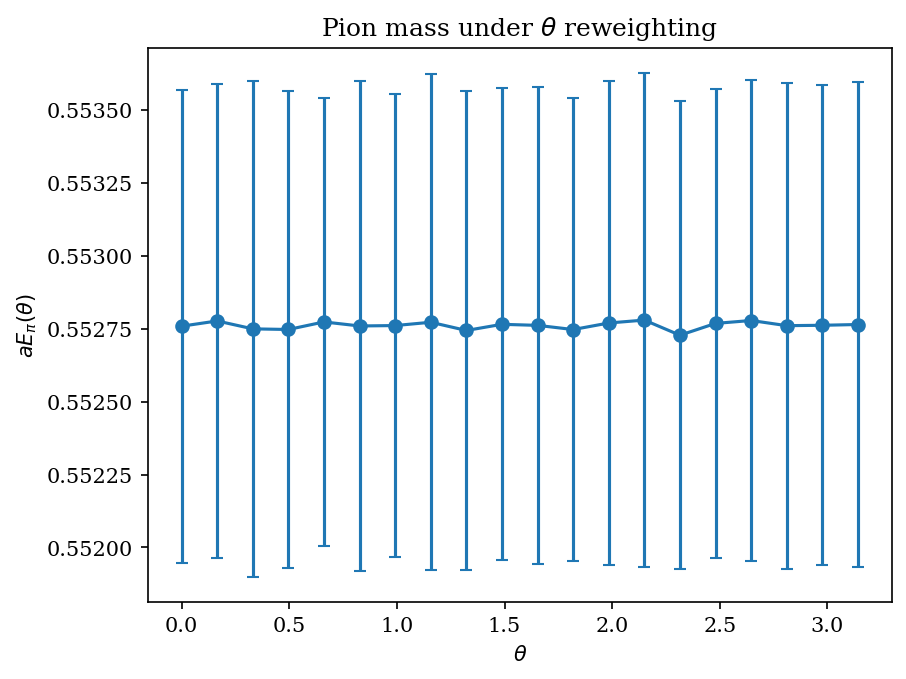

In [10]:
plt.figure(dpi=150)
plt.errorbar(thetas, scan[:,0], yerr=scan[:,1], fmt='o-', capsize=3)
plt.xlabel(r'$\theta$')
plt.ylabel(r'$aE_\pi(\theta)$')
plt.title(r'Pion mass under $\theta$ reweighting')

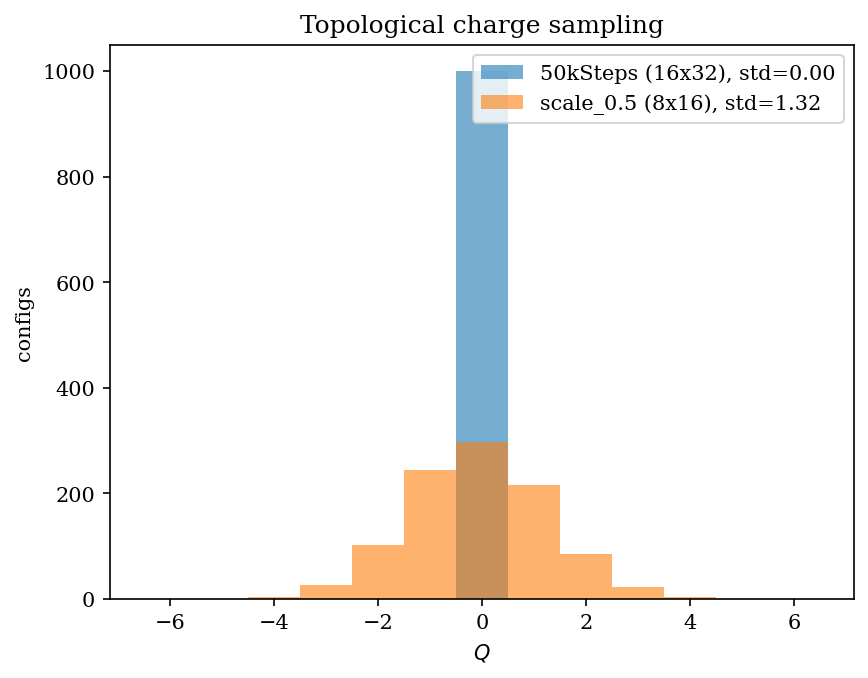

In [11]:
#the fine lattice is topologically frozen (single Q sector over the whole run),
#so its theta reweighting has no Q variance to work with. The coarser scale_0.5
#lattice tunnels between sectors and supports a real theta scan.
with open('configs/50kSteps_scale_0.5.pkl', 'rb') as f:
    model05 = pickle.load(f)

def topCharge(links):
    Ut, Ux = links[:,:,0], links[:,:,1]
    plaq = Ux*np.roll(Ut,-1,0)*np.conj(np.roll(Ux,-1,1))*np.conj(Ut)
    return np.sum(np.angle(plaq))/(2*np.pi)

qsFine   = np.array([topCharge(model.linkHistory[i])   for i in range(0, model.metroSteps, 50)])
qsCoarse = np.array([topCharge(model05.linkHistory[i]) for i in range(0, model05.metroSteps, 50)])

plt.figure(dpi=150)
bins = np.arange(-6.5, 7.5)
plt.hist(np.round(qsFine),   bins=bins, alpha=.6, label=f'50kSteps (16x32), std={qsFine.std():.2f}')
plt.hist(np.round(qsCoarse), bins=bins, alpha=.6, label=f'scale_0.5 (8x16), std={qsCoarse.std():.2f}')
plt.xlabel('$Q$'); plt.ylabel('configs')
plt.title('Topological charge sampling')
plt.legend()

In [12]:
#scale_0.5 GEVP: dimx=8, so nVec=5 keeps complete +-momentum shells (1+2+2)
nVec05 = 5
ops05 = sim.distillation.pionBasis(derivCounts=(0,2), pipiMomenta=(1,2))

dataFile05 = 'configs/50kSteps_scale_0.5_pionBasis_distillData.pkl'
if os.path.exists(dataFile05):
    with open(dataFile05, 'rb') as f:
        data05 = pickle.load(f)
else:
    data05 = sim.distillation.computeInterpCorrelData(model05, ops05, burnIn=0, autocorrSkip=50,
                                                      numVecs=nVec05, cacheDir='distillCache/50kSteps_scale_0.5')
    with open(dataFile05, 'wb') as f:
        pickle.dump(data05, f)

out05 = sim.distillation.interpGEVPStats(model05, ops05, data=data05, theta=0,
                                         ti=ti, numResamples=2000, thermalShift=True)
mean05, errs05, cov05, refVecs05 = out05
nT05 = mean05.shape[0]

content05 = np.abs(refVecs05) / np.linalg.norm(refVecs05, axis=0)
print("            " + "  ".join(f"state{k}" for k in range(len(ops05))))
for iOp in range(len(ops05)):
    print(f"{opNames[iOp]:>12}" + "  ".join(f"{content05[iOp,k]:6.3f}" for k in range(len(ops05))))

            state0  state1  state2  state3
       pi_D0 0.701   0.228   0.442   0.285
       pi_D2 0.710   0.961   0.439   0.311
  pipi_I1_k1 0.018   0.059   0.781   0.008
  pipi_I1_k2 0.059   0.147   0.051   0.907


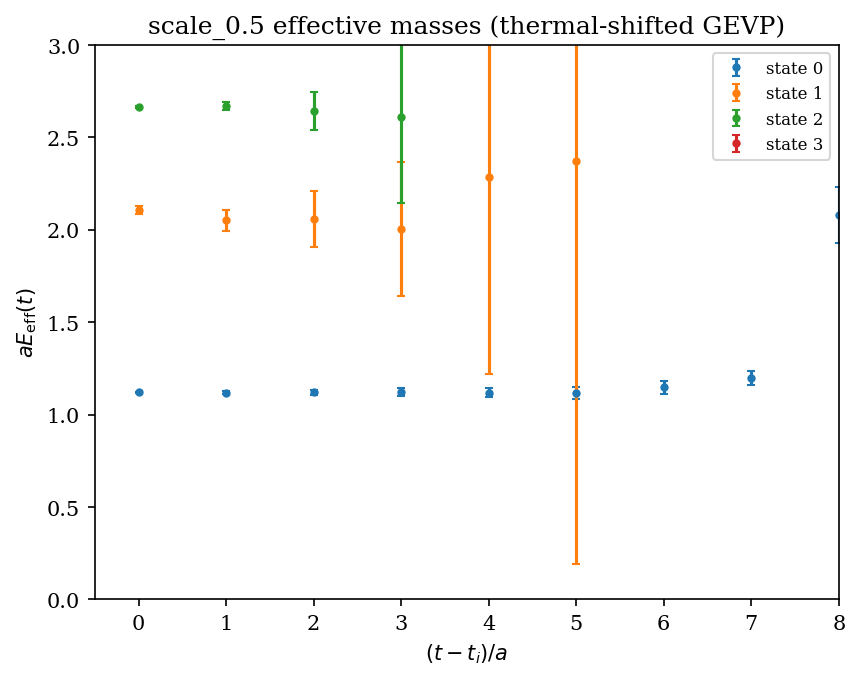

In [13]:
#effective masses on the coarse lattice (dimt=16, so shorter usable range)
plt.figure(dpi=150)
for k in range(len(ops05)):
    C = mean05[:,k]
    with np.errstate(invalid='ignore', divide='ignore'):
        ratio = C[:-1]/C[1:]
        effM = np.log(np.where(ratio > 0, ratio, np.nan))
        dC = errs05.mean(axis=0)[:,k]
        dEff = np.sqrt((dC[:-1]/C[:-1])**2 + (dC[1:]/C[1:])**2)
    plt.errorbar(np.arange(nT05-1), effM, yerr=dEff, fmt='o', ms=3, capsize=2, label=f'state {k}')
plt.xlabel('$(t-t_i)/a$'); plt.ylabel('$aE_{\\mathrm{eff}}(t)$')
plt.xlim(-0.5, 8); plt.ylim(0, 3)
plt.title('scale_0.5 effective masses (thermal-shifted GEVP)')
plt.legend(fontsize=8)

In [14]:
#theta scan on the coarse lattice, where Q actually fluctuates
scan05 = np.array([
    fitGround(sim.distillation.interpGEVPStats(model05, ops05, data=data05, theta=th,
                                               ti=ti, numResamples=500, thermalShift=True),
              lo=2, hi=7)
    for th in tqdm(thetas)
])

  0%|          | 0/20 [00:00<?, ?it/s]

(0.5, 1.5)

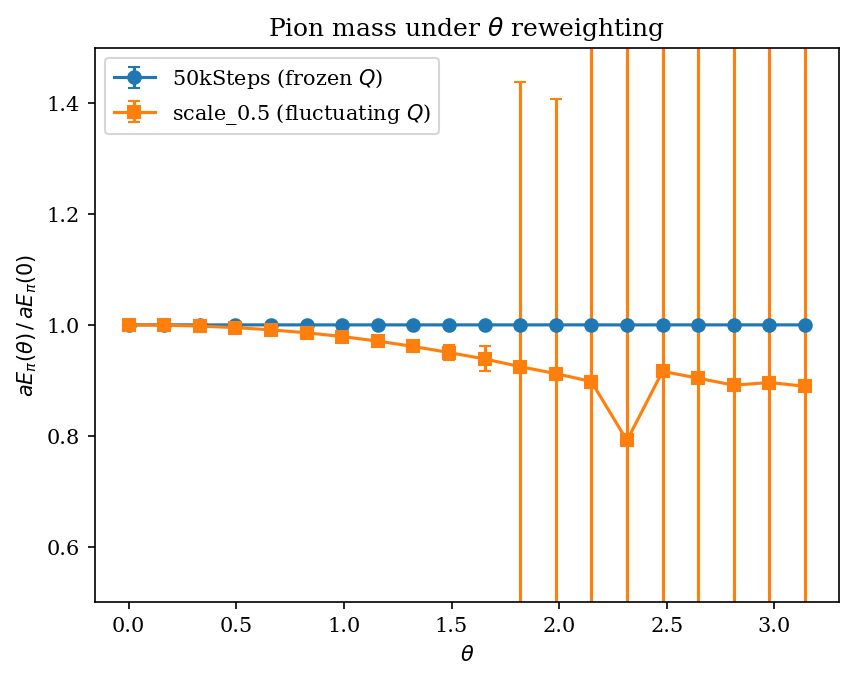

In [15]:
plt.figure(dpi=150)
plt.errorbar(thetas, scan[:,0]/scan[0,0],     yerr=scan[:,1]/scan[0,0],     fmt='o-', capsize=3,
             label='50kSteps (frozen $Q$)')
plt.errorbar(thetas, scan05[:,0]/scan05[0,0], yerr=scan05[:,1]/scan05[0,0], fmt='s-', capsize=3,
             label='scale_0.5 (fluctuating $Q$)')
plt.xlabel(r'$\theta$'); plt.ylabel(r'$aE_\pi(\theta)\,/\,aE_\pi(0)$')
plt.title(r'Pion mass under $\theta$ reweighting')
plt.legend()
plt.ylim([.5,1.5])